In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, make_scorer

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from google.colab import files
import warnings

uploaded = files.upload()

warnings.filterwarnings('ignore')

Saving D00 - wine.data.xlsx to D00 - wine.data (9).xlsx


In [ ]:
df_excel = pd.read_excel("D00 - wine.data.xlsx")
df_excel.to_csv("wine_data.csv", index=False)

df = pd.read_excel("D00 - wine.data.xlsx", sheet_name="wine.data")
# Làm sạch tên cột để bỏ khoảng trắng thừa
df.columns = [str(c).strip() for c in df.columns]

print("=== a. Kích thước và chiều dữ liệu ===")
print(f"Số dòng, số cột: {df.shape}")
print(f"Số chiều: {df.ndim}")

print("\n=== b. Kiểu dữ liệu của các thuộc tính ===")
print(df.dtypes)

print("\n=== c. Số lượng thực thể của các giá trị nhãn ===")
print(df['Class'].value_counts())

print("\n=== d. Giá trị Lớn nhất, Bé nhất, Trung bình ===")
# Chọn các cột có số và loại trừ cột nhãn
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Class', errors='ignore')
stats_df = pd.DataFrame({
    'Max': df[numeric_cols].max(),
    'Min': df[numeric_cols].min(),
    'Mean': df[numeric_cols].mean()
})
display(stats_df)

=== a. Kích thước và chiều dữ liệu ===
Số dòng, số cột: (178, 14)
Số chiều: 2

=== b. Kiểu dữ liệu của các thuộc tính ===
Class                                int64
1) Alcohol                         float64
2) Malic acid                      float64
3) Ash                             float64
4) Alcalinity of ash               float64
5) Magnesium                         int64
6) Total phenols                   float64
7) Flavanoids                      float64
8) Nonflavanoid phenols            float64
9) Proanthocyanins                 float64
10)Color intensity                 float64
11)Hue                             float64
12)OD280/OD315 of diluted wines    float64
13)Proline                           int64
dtype: object

=== c. Số lượng thực thể của các giá trị nhãn ===
Class
2    71
1    59
3    48
Name: count, dtype: int64

=== d. Giá trị Lớn nhất, Bé nhất, Trung bình ===


,Max,Min,Mean
1) Alcohol,14.83,11.03,13.000618
2) Malic acid,5.80,0.74,2.336348
3) Ash,3.23,1.36,2.366517
4) Alcalinity of ash,30.00,10.60,19.494944
5) Magnesium,162.00,70.00,99.741573
6) Total phenols,3.88,0.98,2.295112
7) Flavanoids,5.08,0.34,2.029270
8) Nonflavanoid phenols,0.66,0.13,0.361854
9) Proanthocyanins,3.58,0.41,1.590899
10)Color intensity,13.00,1.28,5.058090


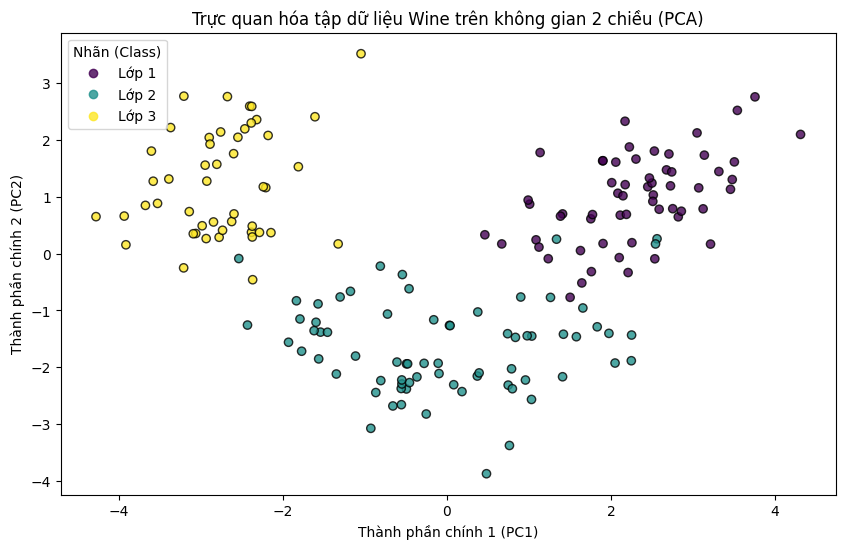

In [ ]:
# Tách đặc trưng và nhãn
X = df.drop('Class', axis=1)
y = df['Class']

# Chuẩn hóa dữ liệu vì giá trị các cột (như Proline) quá chênh lệch
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dùng PCA thu giảm về không gian 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Trực quan hóa
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.8)
plt.title('Trực quan hóa tập dữ liệu Wine trên không gian 2 chiều (PCA)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
handles, labels = scatter.legend_elements()
plt.legend(handles, [f'Lớp {lbl}' for lbl in set(y)], title="Nhãn (Class)")
plt.show()

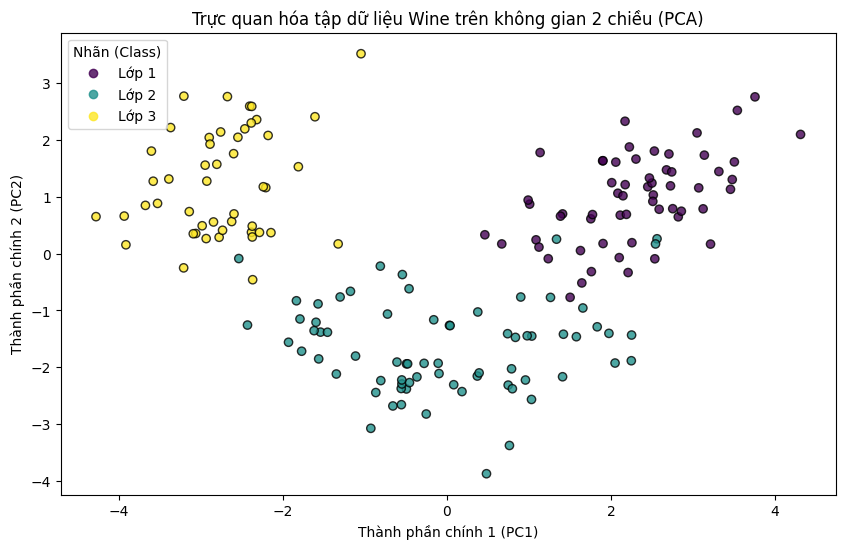

In [ ]:
# Tách đặc trưng và nhãn
X = df.drop('Class', axis=1)
y = df['Class']

# Chuẩn hóa dữ liệu vì giá trị các cột (như Proline) quá chênh lệch
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dùng PCA thu giảm về không gian 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Trực quan hóa
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.8)
plt.title('Trực quan hóa tập dữ liệu Wine trên không gian 2 chiều (PCA)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
handles, labels = scatter.legend_elements()
plt.legend(handles, [f'Lớp {lbl}' for lbl in set(y)], title="Nhãn (Class)")
plt.show()

In [ ]:
# Cấu hình 10-fold Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

# Lựa chọn 3 mô hình từ đề bài
models = {
    'Random Forest': (RandomForestClassifier(random_state=42),
                      {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}),

    'SVM': (SVC(random_state=42),
            {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),

    'KNN': (KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']})
}

results = []

# Huấn luyện và tinh chỉnh bằng GridSearch
for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=cv, scoring=scorer, n_jobs=-1)
    grid.fit(X_scaled, y)

    best_score = grid.best_score_
    best_params = grid.best_params_

    results.append({
        'Mô hình': name,
        'Tham số tốt nhất': str(best_params),
        'F1-Score (Macro)': round(best_score, 4)
    })

results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison.csv", index=False) # Xuất bảng kết quả
display(results_df)

,Mô hình,Tham số tốt nhất,F1-Score (Macro)
0,Random Forest,"{'max_depth': None, 'n_estimators': 50}",0.9893
1,SVM,"{'C': 0.1, 'kernel': 'linear'}",0.9834
2,KNN,"{'n_neighbors': 5, 'weights': 'uniform'}",0.9729


In [ ]:
# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
ari_kmeans = adjusted_rand_score(y, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(y, kmeans_labels)

# 2. DBSCAN
# Các siêu tham số eps và min_samples đã được thử nghiệm để phù hợp nhất có thể
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
ari_dbscan = adjusted_rand_score(y, dbscan_labels)
nmi_dbscan = normalized_mutual_info_score(y, dbscan_labels)

# 3. Đánh giá (So sánh ngược lại với nhãn y)
eval_df = pd.DataFrame({
    'Thuật toán Gom cụm': ['K-Means', 'DBSCAN'],
    'Adjusted Rand Index (ARI)': [ari_kmeans, ari_dbscan],
    'Normalized Mutual Info (NMI)': [nmi_kmeans, nmi_dbscan]
})

print("\n=== Đánh giá hiệu suất phân cụm (Không sử dụng nhãn khi train) ===")
display(eval_df)


=== Đánh giá hiệu suất phân cụm (Không sử dụng nhãn khi train) ===


,Thuật toán Gom cụm,Adjusted Rand Index (ARI),Normalized Mutual Info (NMI)
0,K-Means,0.897495,0.875894
1,DBSCAN,0.220491,0.342514
